In [ ]:
!curl -o dataset.zip https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/ccr8cm22vz-1.zip
!unzip dataset.zip
!unrar x "/content/Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar" > op

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  231M  100  231M    0     0  78.7M      0  0:00:02  0:00:02 --:--:-- 78.7M
Archive:  dataset.zip
replace Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Anemia Detection using Palpable Palm Image Datasets from Ghana/Palm.rar  


Would you like to replace the existing file Palm/Anemic-260 (10).png
 23654 bytes, modified on 2022-06-06 13:41
with a new one
 23654 bytes, modified on 2022-06-06 13:41

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit y


Would you like to replace the existing file Palm/Anemic-260 (11).png
 23081 bytes, modified on 2022-06-08 01:03
with a new one
 23081 bytes, modified on 2022-06-08 01:03

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit y


Would you like to replace the existing file Palm/Anemic-260 (12).png
 23081 bytes, modifi

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

anemic = []
non_anemic = []
for filename in os.listdir('/content/Palm/'):
  if 'Non' in filename:
    non_anemic.append(filename)
  else:
    anemic.append(filename)

In [ ]:
def read_img(filepath):
  img = cv2.imread(filepath)
  img = cv2.resize(img, (227, 227))
  # img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
  # l, a, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
  # return b
  return img

In [ ]:
dataset = []
labels = []
path = '/content/Palm/'
for filename in tqdm(anemic):
  labels.append(0)
  img = read_img(os.path.join(path, filename))
  dataset.append(img)
for filename in tqdm(non_anemic):
  labels.append(1)
  img = read_img(os.path.join(path, filename))
  dataset.append(img)
dataset = np.array(dataset)
labels = np.array(labels)

100%|██████████| 1698/1698 [00:03<00:00, 515.10it/s]


In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf


train_x, test_x, train_y, test_y = train_test_split(dataset, labels, test_size=0.2, random_state=2)
train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.1, random_state=5)
print(train_x.shape, test_x.shape, val_x.shape)
print(train_y.shape, test_y.shape, val_y.shape)

train_x = tf.data.Dataset.from_tensor_slices(train_x)
test_x = tf.data.Dataset.from_tensor_slices(test_x)
val_x = tf.data.Dataset.from_tensor_slices(val_x)

train_y = tf.data.Dataset.from_tensor_slices(train_y)
test_y = tf.data.Dataset.from_tensor_slices(test_y)
val_y = tf.data.Dataset.from_tensor_slices(val_y)

train_ds = tf.data.Dataset.zip((train_x, train_y))
test_ds = tf.data.Dataset.zip((test_x, test_y))
val_ds = tf.data.Dataset.zip((val_x, val_y))


(3067, 227, 227, 3) (852, 227, 227, 3) (341, 227, 227, 3)
(3067,) (852,) (341,)


In [ ]:
from tensorflow import keras

In [ ]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Correctly initialize ConvNeXtTiny without the 'model_name' parameter
base_model = ConvNeXtTiny(
    include_top=False,  # Excludes the fully connected top layer
    include_preprocessing=True,  # Optional preprocessing layer
    weights="imagenet",  # Use pre-trained weights on ImageNet
    input_shape=(224, 224, 3)  # Adjust to your input image size
)

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Define the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
from tensorflow.keras import Input

# Create the input tensor with the desired input shape
input_tensor = Input(shape=(227, 227, 3))

# Load the ConvNeXtTiny model
cnn = keras.applications.ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_tensor=input_tensor
)
cnn.trainable = False

# Define the classifier layers
classifier = keras.models.Sequential(
    [
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dense(2, activation='softmax'),
    ],
    name='classifier'
)

# Create the complete model
model = keras.models.Model(inputs=input_tensor, outputs=classifier(cnn.output))

# Now the model is built and you can see the summary
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 227, 227, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_prestem_no… │ (None, 227, 227, 3)    │              0 │ input_layer_5[0][0]    │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stem        │ (None, 56, 56, 96)     │          4,896 │ convnext_tiny_prestem… │
│ (Sequential)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │          4,800 │ convnext_tiny_stem[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │            192 │ convnext_tiny_stage_0… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 384)    │         37,248 │ convnext_tiny_stage_0… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 384)    │              0 │ convnext_tiny_stage_0… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │         36,960 │ convnext_tiny_stage_0… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │             96 │ convnext_tiny_stage_0… │
│ (LayerScale)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │              0 │ convnext_tiny_stage_0… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_18 (Add)              │ (None, 56, 56, 96)     │              0 │ convnext_tiny_stem[0]… │
│                           │                        │                │ convnext_tiny_stage_0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │          4,800 │ add_18[0][0]           │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ convnext_tiny_stage_0_bl… │ (None, 56, 56, 96)     │            192 │ convnext_tiny_stage_0… │
│ (LayerNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 29,659,234 (113.14 MB)

 Trainable params: 1,839,106 (7.02 MB)

 Non-trainable params: 27,820,128 (106.13 MB)

In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_callbacks = [keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=5,
    verbose=1,
    mode="auto",
    restore_best_weights=True,
    start_from_epoch=40,
)]
batch_size = 16
log = model.fit(train_ds.batch(batch_size), epochs=100, verbose=2, validation_data=val_ds.batch(batch_size),
                  callbacks=model_callbacks)

Epoch 1/100
192/192 - 59s - 310ms/step - accuracy: 0.7049 - loss: 0.5844 - val_accuracy: 0.8446 - val_loss: 0.3760
Epoch 2/100
192/192 - 2s - 10ms/step - accuracy: 0.8627 - loss: 0.3038 - val_accuracy: 0.9003 - val_loss: 0.2480
Epoch 3/100
192/192 - 2s - 10ms/step - accuracy: 0.9279 - loss: 0.1875 - val_accuracy: 0.8563 - val_loss: 0.3500
Epoch 4/100
192/192 - 2s - 10ms/step - accuracy: 0.9465 - loss: 0.1300 - val_accuracy: 0.9179 - val_loss: 0.2017
Epoch 5/100
192/192 - 2s - 10ms/step - accuracy: 0.9677 - loss: 0.0837 - val_accuracy: 0.9091 - val_loss: 0.2403
Epoch 6/100
192/192 - 2s - 10ms/step - accuracy: 0.9710 - loss: 0.0815 - val_accuracy: 0.9238 - val_loss: 0.1965
Epoch 7/100
192/192 - 2s - 10ms/step - accuracy: 0.9788 - loss: 0.0630 - val_accuracy: 0.8915 - val_loss: 0.4349
Epoch 8/100
192/192 - 2s - 10ms/step - accuracy: 0.9824 - loss: 0.0436 - val_accuracy: 0.8446 - val_loss: 0.6300
Epoch 9/100
192/192 - 2s - 10ms/step - accuracy: 0.9830 - loss: 0.0467 - val_accuracy: 0.9238 

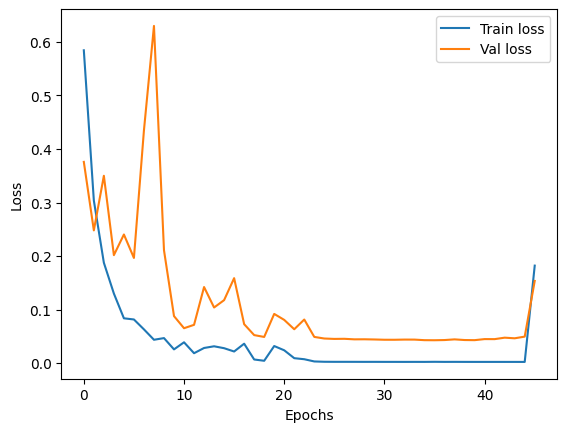

Model performance on test dataset: 
Loss: 0.16082525253295898
Accuracy: 0.9647887349128723
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step
[[516  14]
 [ 16 306]]
Model performance on train dataset: 
Loss: 0.0020997265819460154
Accuracy: 0.9990218281745911
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
[[1830    3]
 [   0 1234]]


In [ ]:
from matplotlib import pyplot as plt
plt.plot(log.history['loss'])
plt.plot(log.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train loss", "Val loss"])
plt.show()

loss, acc = model.evaluate(test_ds.batch(batch_size), verbose=0)
print("Model performance on test dataset: ")
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")

y_pred = model.predict(test_x.batch(batch_size))
y_pred = tf.math.argmax(
    y_pred,
    axis=1)
y_test_list = list(test_y.as_numpy_iterator())
cm = tf.math.confusion_matrix(y_test_list, y_pred).numpy()
print(cm)

loss, acc = model.evaluate(train_ds.batch(batch_size), verbose=0)
print("Model performance on train dataset: ")
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")

y_pred = model.predict(train_x.batch(batch_size))
y_pred = tf.math.argmax(
    y_pred,
    axis=1)
y_train_list = list(train_y.as_numpy_iterator())
cm = tf.math.confusion_matrix(y_train_list, y_pred).numpy()
print(cm)

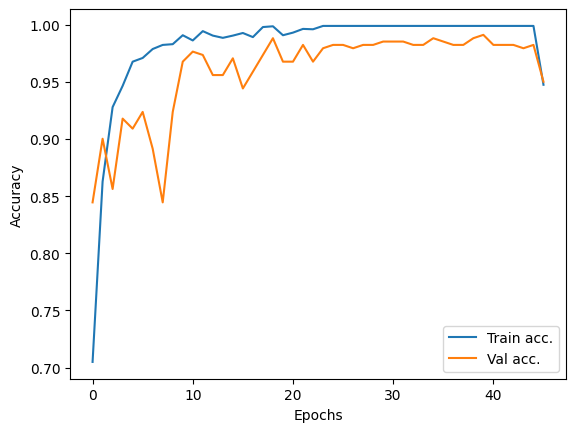

In [ ]:
plt.plot(log.history['accuracy'])
plt.plot(log.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train acc.", "Val acc."])
plt.show()

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
filepath = './drive/MyDrive/anemia-classifier-ConvNeXtTiny.weights.h5'
classifier.save_weights(filepath, overwrite=True)



In [24]:
classifier.load_weights(filepath)
model = keras.models.Sequential(
    [
        cnn,
        classifier,
    ]
)
batch_size=16
y_pred = model.predict(test_x.batch(batch_size))
y_pred = tf.math.argmax(
    y_pred,
    axis=1)
y_test_list = list(test_y.as_numpy_iterator())
cm = tf.math.confusion_matrix(y_test_list, y_pred).numpy()
print(cm)

54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step
[[516  14]
 [ 16 306]]


In [31]:
accuracy = (cm[0,0]+cm[1,1])/(cm[0,0]+cm[1,1]+cm[0,1]+cm[1,0])
print("Accuracy: ", accuracy)

precision = (cm[0,0])/(cm[0,0]+cm[0,1])
print("Precision: ", precision)

recall = (cm[0,0])/(cm[0,0]+cm[1,0])
print("Precision: ", recall)

f1score = 2*(1/precision + 1/recall)
print("F1-score: ", f1score)

f1score = 2*((precision*recall)/(precision+recall))
print("F1-score: ", f1score)

Accuracy:  0.9647887323943662
Precision:  0.9735849056603774
Precision:  0.9699248120300752
F1-score:  4.116279069767442
F1-score:  0.9717514124293785
